In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/fasgadhsxnzmjj/tmpdataset/train.csv
/kaggle/input/datasets/fasgadhsxnzmjj/tmpdataset/test.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/centralVN_dataWeather.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/aqi_centralVN_daily.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/aqi_southVN_daily.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN_dataThoiTiet.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/southVN_dataAIR.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/centralVN.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/southVN_dataWeather.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/centralVN_dataAIR.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN_dataAIR.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/southVN.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN.csv
/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/aqi_northVN_daily.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/fasgadhsxnzmjj/mmd-dataset/northVN.csv")

In [3]:
df.head()

,district,city,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),rain (mm),cloud_cover (%),cloud_cover_low (%),...,pm2_5 (μg/m³),carbon_monoxide (μg/m³),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),ozone (μg/m³),aerosol_optical_depth (),dust (μg/m³),uv_index (),uv_index_clear_sky (),aqi_h
0,Ba Dinh,Ha Noi,2022-08-04 07:00:00,28.5,87,35.2,0.0,0.0,8,0,...,40.3,595.0,29.7,16.8,24.0,0.43,0.0,0.75,0.80,81
1,Ba Dinh,Ha Noi,2022-08-04 08:00:00,29.5,82,36.6,0.0,0.0,100,0,...,30.0,552.0,25.0,18.2,49.0,0.52,0.0,2.10,2.35,72
2,Ba Dinh,Ha Noi,2022-08-04 09:00:00,30.4,80,38.0,0.0,0.0,100,5,...,32.7,492.0,18.4,20.2,84.0,0.59,0.0,3.95,4.55,70
3,Ba Dinh,Ha Noi,2022-08-04 10:00:00,31.8,73,39.4,0.0,0.0,94,23,...,34.9,429.0,11.2,22.0,128.0,0.68,0.0,4.70,6.75,70
4,Ba Dinh,Ha Noi,2022-08-04 11:00:00,32.5,71,41.1,0.0,0.0,92,3,...,38.3,414.0,8.6,21.5,154.0,0.75,0.0,5.10,8.25,71


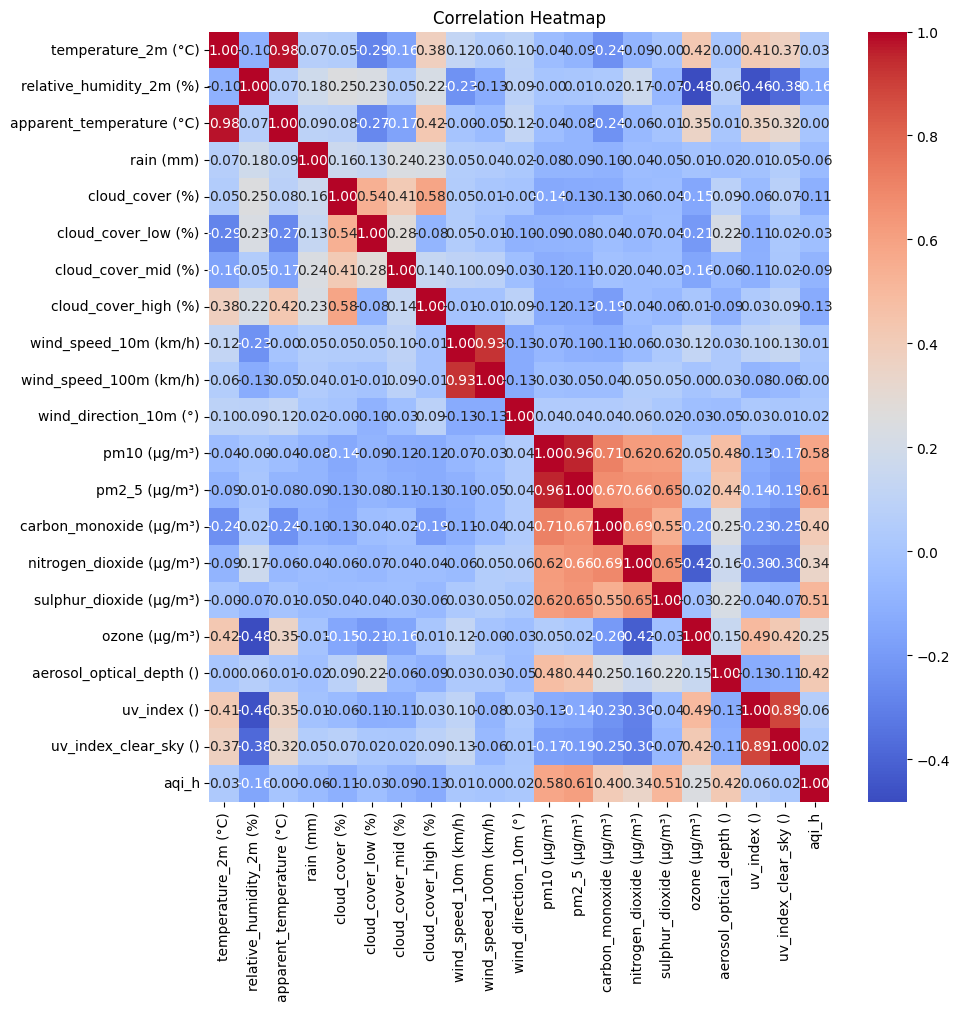

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# ví dụ dữ liệu
df1 = df[[
'temperature_2m (°C)',
'relative_humidity_2m (%)',
'apparent_temperature (°C)',
'rain (mm)',
'cloud_cover (%)',
'cloud_cover_low (%)',
'cloud_cover_mid (%)',
'cloud_cover_high (%)',
'wind_speed_10m (km/h)',
'wind_speed_100m (km/h)',
'wind_direction_10m (°)',
'pm10 (μg/m³)',
'pm2_5 (μg/m³)',
'carbon_monoxide (μg/m³)',
'nitrogen_dioxide (μg/m³)',
'sulphur_dioxide (μg/m³)',
'ozone (μg/m³)',
'aerosol_optical_depth ()',
'uv_index ()',
'uv_index_clear_sky ()',
'aqi_h']]

# ma trận tương quan
corr = df1.corr()
# print(corr)

# vẽ heatmap
plt.figure(figsize=(10,10))

sns.heatmap(
    corr,
    annot=True,      # hiện số
    cmap='coolwarm', # màu
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

AQI có mối tương quan cao với:  
pm10  
pm25  
co  
no2  
so2  
aod(độ trong khí quyển)  

In [5]:
df2 = df[(df['city'] == 'Ha Noi') & (df['district'] == 'Thanh Xuan')]
df2.head()

,district,city,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),rain (mm),cloud_cover (%),cloud_cover_low (%),...,pm2_5 (μg/m³),carbon_monoxide (μg/m³),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),ozone (μg/m³),aerosol_optical_depth (),dust (μg/m³),uv_index (),uv_index_clear_sky (),aqi_h
214655,Thanh Xuan,Ha Noi,2022-08-04 07:00:00,28.3,86,34.8,0.0,0.0,40,0,...,41.7,713.0,38.6,20.1,22.0,0.34,0.0,0.75,0.85,83
214656,Thanh Xuan,Ha Noi,2022-08-04 08:00:00,29.5,82,36.5,0.0,0.0,99,0,...,29.9,658.0,32.8,21.0,50.0,0.39,0.0,2.20,2.50,74
214657,Thanh Xuan,Ha Noi,2022-08-04 09:00:00,30.6,79,38.1,0.0,0.0,100,4,...,30.4,581.0,24.4,22.5,90.0,0.47,0.0,3.90,4.85,71
214658,Thanh Xuan,Ha Noi,2022-08-04 10:00:00,31.8,75,39.8,0.0,0.0,99,10,...,35.5,503.0,15.8,24.0,137.0,0.57,0.0,5.20,7.15,71
214659,Thanh Xuan,Ha Noi,2022-08-04 11:00:00,32.5,72,41.2,0.0,0.0,92,4,...,44.0,490.0,13.5,24.4,160.0,0.68,0.0,5.45,8.55,72


In [6]:
df2.shape

(30665, 34)

In [10]:
dftrain = pd.read_csv('/kaggle/input/datasets/fasgadhsxnzmjj/tmpdataset/train.csv')
dftrain.head()

,district,time,pm2_5 (μg/m³),pm10 (μg/m³),carbon_monoxide (μg/m³),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),ozone (μg/m³),aerosol_optical_depth (),aqi_h
0,Thanh Xuan,2022-08-04 07:00:00,41.7,60.1,713.0,38.6,20.1,22.0,0.34,83
1,Thanh Xuan,2022-08-04 08:00:00,29.9,43.3,658.0,32.8,21.0,50.0,0.39,74
2,Thanh Xuan,2022-08-04 09:00:00,30.4,44.0,581.0,24.4,22.5,90.0,0.47,71
3,Thanh Xuan,2022-08-04 10:00:00,35.5,51.2,503.0,15.8,24.0,137.0,0.57,71
4,Thanh Xuan,2022-08-04 11:00:00,44.0,63.3,490.0,13.5,24.4,160.0,0.68,72


In [4]:
dftest = pd.read_csv('/kaggle/input/datasets/fasgadhsxnzmjj/tmpdataset/test.csv')
dftest.head()

,district,time,pm2_5 (μg/m³),pm10 (μg/m³),carbon_monoxide (μg/m³),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),ozone (μg/m³),aerosol_optical_depth (),aqi_h
0,Thanh Xuan,2025-05-22 11:00:00,39.7,40.3,413.0,13.0,30.3,193.0,0.75,91
1,Thanh Xuan,2025-05-22 12:00:00,37.5,38.1,393.0,12.1,28.1,194.0,0.87,92
2,Thanh Xuan,2025-05-22 13:00:00,36.3,36.9,385.0,12.5,26.6,188.0,0.84,85
3,Thanh Xuan,2025-05-22 14:00:00,38.4,38.9,394.0,14.5,26.5,175.0,0.70,69
4,Thanh Xuan,2025-05-22 15:00:00,37.4,38.3,414.0,17.9,27.1,155.0,0.59,74


In [11]:
dftrain['time'] = pd.to_datetime(dftrain['time'])
dftrain['time'] = dftrain['time'].dt.weekday
dftrain = dftrain.drop('district', axis = 1)
dftrain.head()
y_train = dftrain['aqi_h']
x_train = dftrain.drop('aqi_h', axis = 1)

In [12]:
dftest['time'] = pd.to_datetime(dftest['time'])
dftest['time'] = dftest['time'].dt.weekday
dftest = dftest.drop('district', axis = 1)
dftest.head()
y_test = dftest['aqi_h']
x_test = dftest.drop('aqi_h', axis = 1)
print(y_test.head())
print(x_test.head())

0    91
1    92
2    85
3    69
4    74
Name: aqi_h, dtype: int64
   time  pm2_5 (μg/m³)  pm10 (μg/m³)  carbon_monoxide (μg/m³)  \
0     3           39.7          40.3                    413.0   
1     3           37.5          38.1                    393.0   
2     3           36.3          36.9                    385.0   
3     3           38.4          38.9                    394.0   
4     3           37.4          38.3                    414.0   

   nitrogen_dioxide (μg/m³)  sulphur_dioxide (μg/m³)  ozone (μg/m³)  \
0                      13.0                     30.3          193.0   
1                      12.1                     28.1          194.0   
2                      12.5                     26.6          188.0   
3                      14.5                     26.5          175.0   
4                      17.9                     27.1          155.0   

   aerosol_optical_depth ()  
0                      0.75  
1                      0.87  
2                      0.8

In [13]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


regressor = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=5)
regressor.fit(x_train, y_train)

predictions = regressor.predict(x_test)
mae = mean_absolute_error(y_test, predictions)
rmse = root_mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f'Mean Absolute Error: {mae}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R-squared: {r2}')

Mean Absolute Error: 32.84642699069993
Root Mean Squared Error: 40.04632676344122
R-squared: 0.21403961644037872


In [15]:
trees = [100, 200, 300, 400, 500]
mae_rf = []
rmse_rf = []
r2_rf = []
for i in trees:
    print('số cây', i)
    regressor = RandomForestRegressor(n_estimators=i, random_state=42, max_depth=15)
    regressor.fit(x_train, y_train)
    predictions = regressor.predict(x_test)
    mae_rf.append(mean_absolute_error(y_test, predictions))
    rmse_rf.append(root_mean_squared_error(y_test, predictions))
    r2_rf.append(r2_score(y_test, predictions))

số cây 100
số cây 200
số cây 300
số cây 400
số cây 500


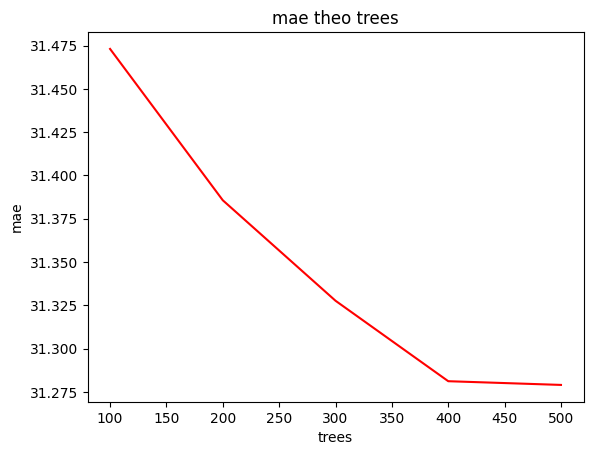

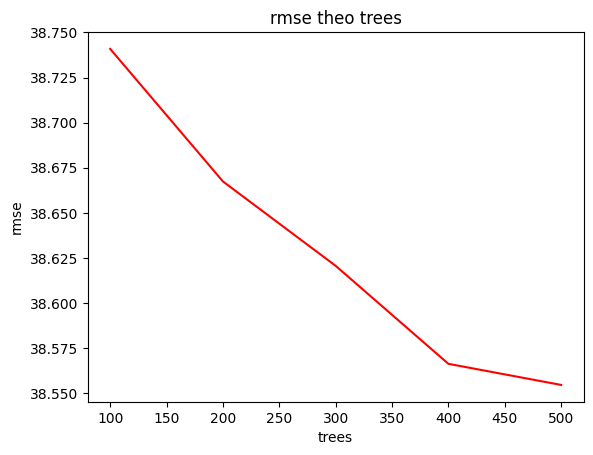

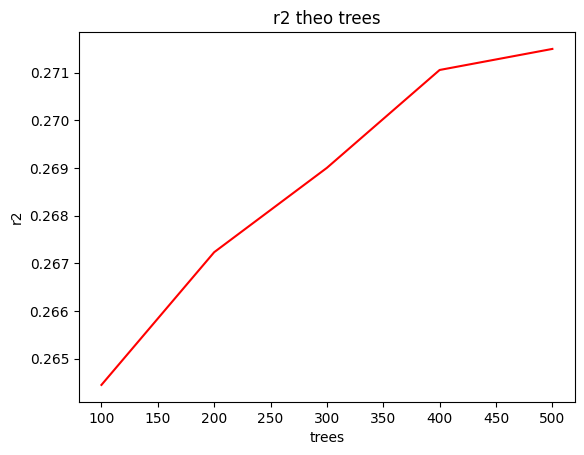

In [17]:
import matplotlib.pyplot as plt

plt.plot(trees, mae_rf, color = 'red')
plt.xlabel('trees')
plt.ylabel('mae')
plt.title('mae theo trees')
plt.show()

plt.plot(trees, rmse_rf, color = 'red')
plt.xlabel('trees')
plt.ylabel('rmse')
plt.title('rmse theo trees')
plt.show()

plt.plot(trees, r2_rf, color = 'red')
plt.xlabel('trees')
plt.ylabel('r2')
plt.title('r2 theo trees')
plt.show()

400 cây quyết định là đẹp

In [19]:
import matplotlib.pyplot as plt

depths = range(5,20)
mae = []
rmse = []
r2 = []
for i in depths:
    print('depths thứ', i)
    regressor = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=i)
    regressor.fit(x_train, y_train)
    predictions = regressor.predict(x_test)
    mae.append(mean_absolute_error(y_test, predictions))
    rmse.append(root_mean_squared_error(y_test, predictions))
    r2.append(r2_score(y_test, predictions))

depths thứ 5
depths thứ 6
depths thứ 7
depths thứ 8
depths thứ 9
depths thứ 10
depths thứ 11
depths thứ 12
depths thứ 13
depths thứ 14
depths thứ 15
depths thứ 16
depths thứ 17
depths thứ 18
depths thứ 19


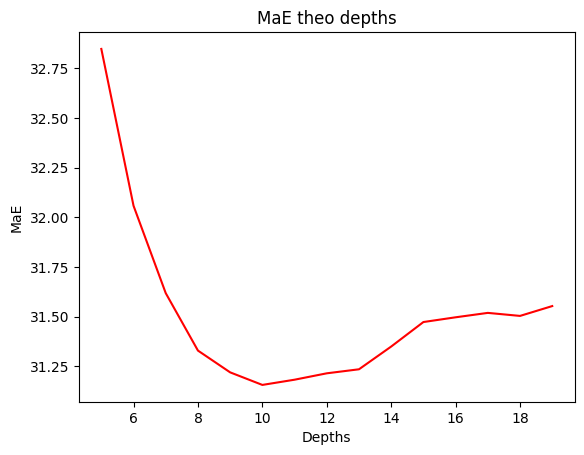

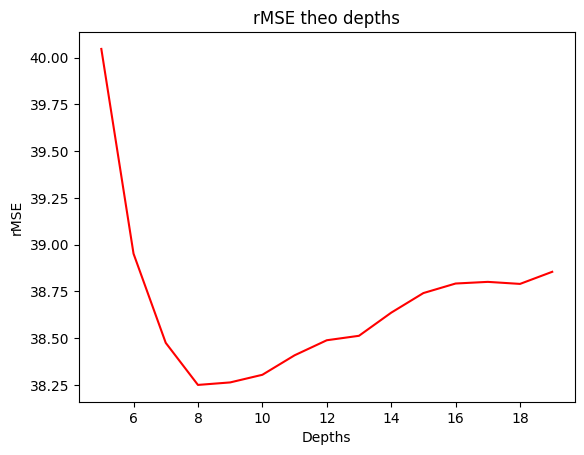

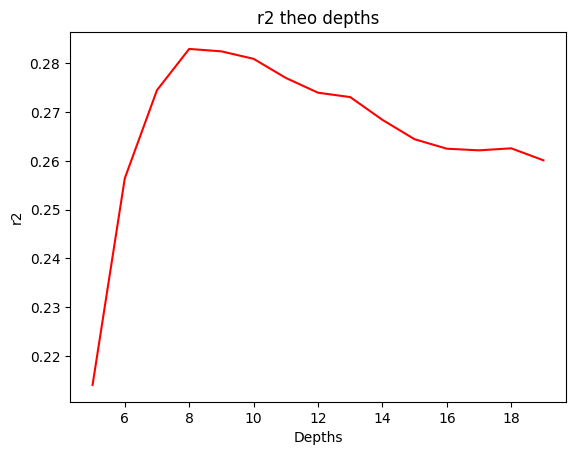

In [20]:
plt.plot(depths, mae, color = 'red')
plt.xlabel('Depths')
plt.ylabel('MaE')
plt.title('MaE theo depths')
plt.show()

plt.plot(depths, rmse, color = 'red')
plt.xlabel('Depths')
plt.ylabel('rMSE')
plt.title('rMSE theo depths')
plt.show()

plt.plot(depths, r2, color = 'red')
plt.xlabel('Depths')
plt.ylabel('r2')
plt.title('r2 theo depths')
plt.show()

9 depth là đẹp

In [21]:
regressor = RandomForestRegressor(n_estimators=400, random_state=42, max_depth=9)
regressor.fit(x_train, y_train)
predictions = regressor.predict(x_test)
print(mean_absolute_error(y_test, predictions))
print(root_mean_squared_error(y_test, predictions))
print(r2_score(y_test, predictions))

31.142564130245056
38.15077436465508
0.28668394768988914


In [24]:
from sklearn.tree import DecisionTreeRegressor

mae_dt = []
rmse_dt = []
r2_dt = []
# Tạo model
for i in depths:
    print('depths thứ', i)
    dt = DecisionTreeRegressor(
    max_depth=i,
    random_state=42
    )

    # Train
    dt.fit(x_train, y_train)
    
    # Predict
    pred = dt.predict(x_test)
    
    # Metric
    mae_dt.append(mean_absolute_error(y_test, pred))
    rmse_dt.append(root_mean_squared_error(y_test, pred))
    r2_dt.append(r2_score(y_test, pred))

depths thứ 5
depths thứ 6
depths thứ 7
depths thứ 8
depths thứ 9
depths thứ 10
depths thứ 11
depths thứ 12
depths thứ 13
depths thứ 14
depths thứ 15
depths thứ 16
depths thứ 17
depths thứ 18
depths thứ 19


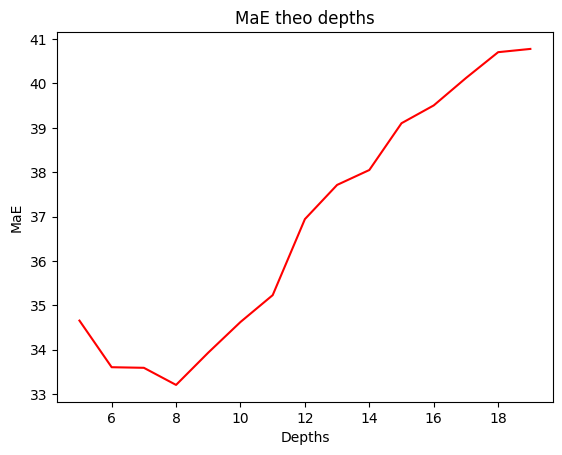

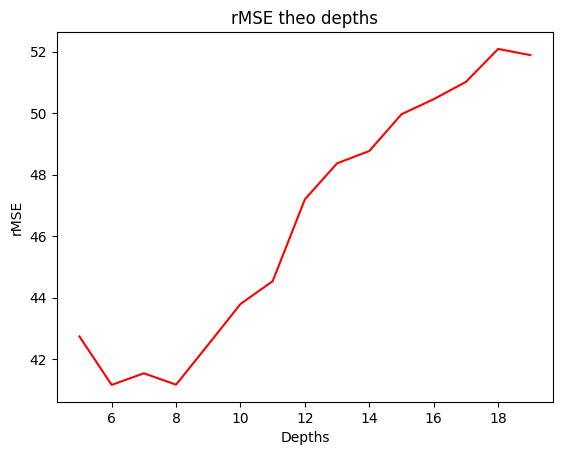

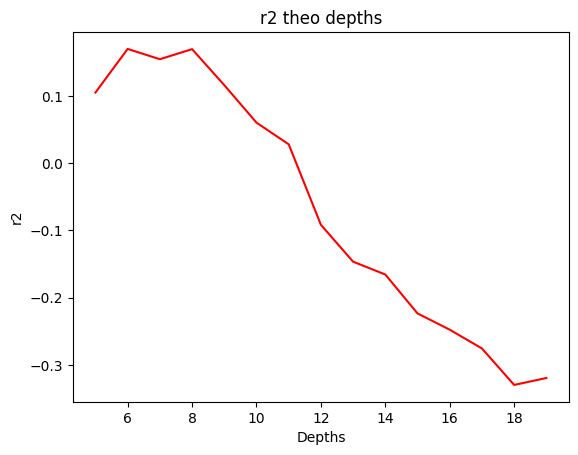

In [25]:
plt.plot(depths, mae_dt, color = 'red')
plt.xlabel('Depths')
plt.ylabel('MaE')
plt.title('MaE theo depths')
plt.show()

plt.plot(depths, rmse_dt, color = 'red')
plt.xlabel('Depths')
plt.ylabel('rMSE')
plt.title('rMSE theo depths')
plt.show()

plt.plot(depths, r2_dt, color = 'red')
plt.xlabel('Depths')
plt.ylabel('r2')
plt.title('r2 theo depths')
plt.show()

8 là ngon luôn 

In [27]:
dt = DecisionTreeRegressor(
    max_depth=8,
    random_state=42
    )

# Train
dt.fit(x_train, y_train)

# Predict
pred = dt.predict(x_test)

# Metric
print(mean_absolute_error(y_test, pred))
print(root_mean_squared_error(y_test, pred))
print(r2_score(y_test, pred))

33.20674377413916
41.163950538461776
0.16955786204899304


So sánh với randomforest đều tệ hơn 